In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.metrics import mean_squared_error,mean_absolute_error
from math import sqrt
# holt winters
# single exponential smoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
# double and triple exponential smoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
path= '/content/drive/MyDrive/KuliahRPD/ricesupply_2011-2025.csv'

DATA DETAILS

In [ ]:
df= pd.read_csv(path, index_col='Bulan', parse_dates=True)
df.index.freq='MS'
df.head()

,Unnamed: 0,Tahun,Karawang,Cirebon,Bandung,Cianjur,Banten,Jateng,Jatim,Gdg.Jkt,Bulog,Anpu,Total Pasokan
Bulan,,,,,,,,,,,,,
2011-01-01,1,2011,11114,14991,7175,543,229,16269,4279,2427,22030,177,79234
2011-02-01,2,2011,13527,18099,7228,519,767,14965,2745,1617,5445,112,65024
2011-03-01,3,2011,22420,26227,9337,563,590,9145,907,960,5190,193,75532
2011-04-01,4,2011,23075,26939,8264,587,251,5152,446,280,25,78,65097
2011-05-01,5,2011,23708,27555,8911,674,474,6707,749,802,0,55,69635


In [ ]:
df.drop(columns='Unnamed: 0',inplace=True)

In [ ]:
df.head()

,Tahun,Karawang,Cirebon,Bandung,Cianjur,Banten,Jateng,Jatim,Gdg.Jkt,Bulog,Anpu,Total Pasokan
Bulan,,,,,,,,,,,,
2011-01-01,2011,11114,14991,7175,543,229,16269,4279,2427,22030,177,79234
2011-02-01,2011,13527,18099,7228,519,767,14965,2745,1617,5445,112,65024
2011-03-01,2011,22420,26227,9337,563,590,9145,907,960,5190,193,75532
2011-04-01,2011,23075,26939,8264,587,251,5152,446,280,25,78,65097
2011-05-01,2011,23708,27555,8911,674,474,6707,749,802,0,55,69635


<Axes: xlabel='Bulan'>

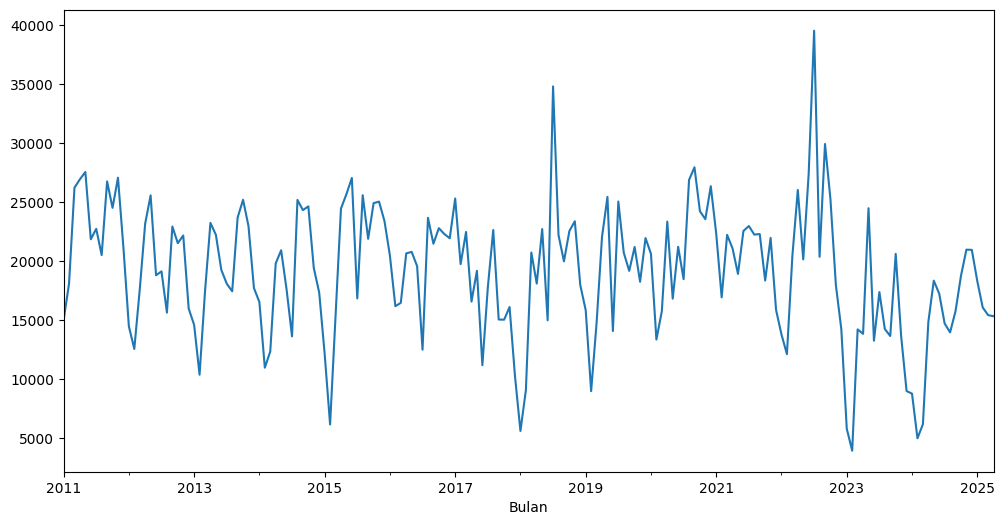

In [ ]:
df['Jateng'].plot(figsize=(12,6))

In [ ]:
df2=df.filter(items = ['Bulan','Cirebon'], axis = 1)
df2.head()

,Cirebon
Bulan,
2011-01-01,14991
2011-02-01,18099
2011-03-01,26227
2011-04-01,26939
2011-05-01,27555


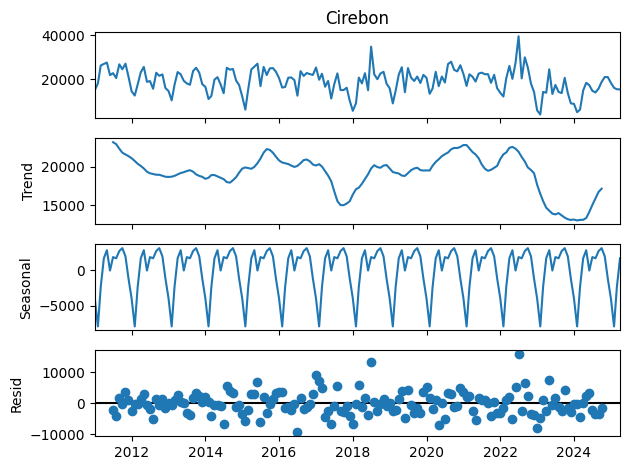

In [ ]:
results = seasonal_decompose(df2['Cirebon'])
results.plot();

MODEL 1 LAPIS LSTM

In [ ]:
train = df2.iloc[:135]
test = df2.iloc[135:]
len(df)

172

Kode itu artinya Anda membagi data df2 berdasarkan urutan baris:

train = df2.iloc[:140] → ambil baris indeks posisi 0 s.d. 139 (total 140 baris) untuk data latih.

test = df2.iloc[140:] → ambil baris indeks posisi 140 s.d. terakhir untuk data uji.

Catatan penting:

Ini bukan split acak (tidak shuffle). Cocok untuk time series / data berurutan.

Pastikan df2 sudah diurutkan (mis. berdasarkan tanggal) sebelum split, kalau konteksnya time series.

In [ ]:
scaler = MinMaxScaler()
scaler.fit(train)
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)
scaled_train[:10]

array([[0.27643068],
       [0.36811209],
       [0.60787611],
       [0.62887906],
       [0.64705015],
       [0.47899705],
       [0.50498525],
       [0.43952802],
       [0.62342183],
       [0.55740413]])

In [ ]:
# define generator
n_input = 3 # Jumlah data sebelumnya yang digunakan untuk memprediksi 1 titik berikutnya
n_features = 1  # Jumlah fitur per timestep (dalam kasus ini: hanya 1, yaitu jumlah pasokan beras)

generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)
X,y = generator[0]
print(f'Given the Array: \n{X.flatten()}')
print(f'Predict this y: \n {y}')

Given the Array: 
[0.27643068 0.36811209 0.60787611]
Predict this y: 
 [[0.62887906]]


chatgpt : Dengan scaled_train adalah data deret waktu yang sudah dinormalisasi (misalnya data pasokan beras per bulan), TimeseriesGenerator akan otomatis membuat:

X berisi 3 bulan terakhir

y adalah bulan berikutnya

In [ ]:
# We do the same thing, but now instead for 12 months
n_input = 12
generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)

Jika data fluktuatif jangka pendek → Gunakan n_input = 3
Jika data musiman atau tren panjang → Gunakan n_input = 12


In [ ]:
# define model
model = Sequential() # Membuat model sekuensial—artinya layer akan ditambahkan satu per satu secara berurutan.
model.add(LSTM(100, activation='relu', input_shape=(n_input, n_features)))
model.add(Dense(1)) # Output layer: 1 neuron, karena kita hanya ingin memprediksi 1 nilai output (misal: jumlah pasokan bulan depan).
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


model.add(LSTM(100, activation='relu', input_shape=(n_input, n_features)))

Menambahkan LSTM layer dengan 100 unit (neuron).

activation='relu' → ReLU dipakai agar model bisa belajar non-linearitas. Catatan: default LSTM biasanya memakai tanh; pakai ReLU hanya jika sudah dicoba dan terbukti lebih baik.

input_shape=(n_input, n_features) → input ke LSTM berupa urutan sepanjang n_input (misalnya 12 bulan terakhir), masing-masing dengan n_features variabel (biasanya 1 untuk univariat).

model.compile(optimizer='adam', loss='mse')
optimizer='adam' → optimisasi adaptif yang sering dipakai karena cepat konvergen.

loss='mse' → Mean Squared Error, cocok untuk regresi seperti forecasting.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# fit model
model.fit(generator,epochs=50)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0531
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0229
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0257
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0249
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0217
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0209
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0190
Epoch 8/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0171
Epoch 9/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0192
Epoch 10/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0282
Epoch 11/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0224
Epoch 12/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0196
Epoch 13/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0222
Epoch 14/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0178
Epoch 15/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - l

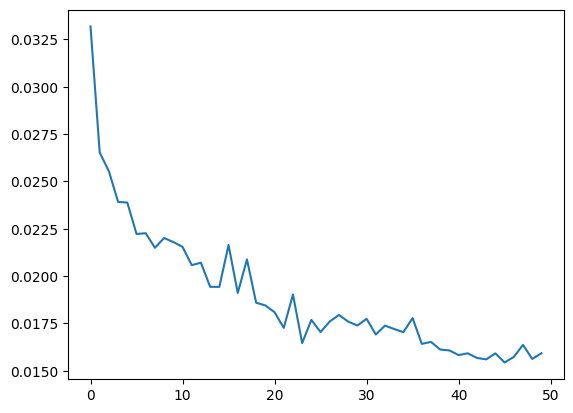

In [ ]:
loss_per_epoch = model.history.history['loss']
plt.plot(range(len(loss_per_epoch)),loss_per_epoch)

In [ ]:
last_train_batch = scaled_train[-12:]
last_train_batch = last_train_batch.reshape((1, n_input, n_features))
print(model.predict(last_train_batch))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
[[0.4801624]]


In [ ]:
scaled_test[0]

array([0.71707965])

In [ ]:
test_predictions = []

first_eval_batch = scaled_train[-n_input:]
current_batch = first_eval_batch.reshape((1, n_input, n_features))

for i in range(len(test)):

    # get the prediction value for the first batch
    current_pred = model.predict(current_batch)[0]

    # append the prediction into the array
    test_predictions.append(current_pred)

    # use the prediction to update the batch and remove the first value
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━

In [ ]:
test_predictions

[array([0.4801624], dtype=float32),
 array([0.44206658], dtype=float32),
 array([0.4419624], dtype=float32),
 array([0.3546884], dtype=float32),
 array([0.26668084], dtype=float32),
 array([0.21606272], dtype=float32),
 array([0.3182644], dtype=float32),
 array([0.4501867], dtype=float32),
 array([0.46319425], dtype=float32),
 array([0.5372456], dtype=float32),
 array([0.6164072], dtype=float32),
 array([0.50426906], dtype=float32),
 array([0.4887781], dtype=float32),
 array([0.46032125], dtype=float32),
 array([0.4351489], dtype=float32),
 array([0.3808093], dtype=float32),
 array([0.2931223], dtype=float32),
 array([0.22170165], dtype=float32),
 array([0.25904065], dtype=float32),
 array([0.35176742], dtype=float32),
 array([0.42268845], dtype=float32),
 array([0.48376378], dtype=float32),
 array([0.5261593], dtype=float32),
 array([0.50375706], dtype=float32),
 array([0.49017256], dtype=float32),
 array([0.47073483], dtype=float32),
 array([0.44513315], dtype=float32),
 array([0.404

In [ ]:
test.head()

,Cirebon
Bulan,
2022-09-01,29929
2022-10-01,25262
2022-11-01,17969
2022-12-01,14246
2023-01-01,5816


In [ ]:
true_predictions = scaler.inverse_transform(test_predictions)
test['Predictions'] = true_predictions

<ipython-input-25-df68ac2ffec1>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


<Axes: xlabel='Bulan'>

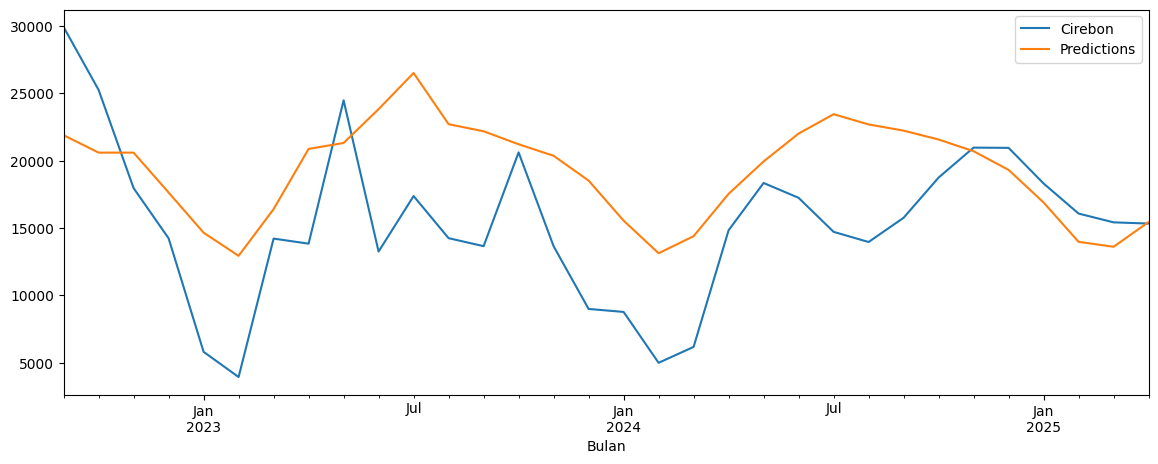

In [ ]:
test.plot(figsize=(14,5))

In [ ]:
rmse_model1=sqrt(mean_squared_error(test['Cirebon'],test['Predictions']))
print(f'Mean squared error : {rmse_model1}')

Mean squared error : 6201.788081170297


In [ ]:
test.head()

,Karawang,Predictions
Bulan,,
2021-01-01,20310,19483.153456
2021-02-01,14233,14447.480577
2021-03-01,18697,13001.107126


MODEL 2 LAPIS LSTM

In [ ]:
train = df2.iloc[:140]
test = df2.iloc[140:]
len(df)

172

In [ ]:
scaler = MinMaxScaler()
scaler.fit(train)
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)
scaled_train[:10]

array([[0.27643068],
       [0.36811209],
       [0.60787611],
       [0.62887906],
       [0.64705015],
       [0.47899705],
       [0.50498525],
       [0.43952802],
       [0.62342183],
       [0.55740413]])

In [ ]:
# define generator
n_input = 3
n_features = 1
generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)
X,y = generator[0]
print(f'Given the Array: \n{X.flatten()}')
print(f'Predict this y: \n {y}')

Given the Array: 
[0.27643068 0.36811209 0.60787611]
Predict this y: 
 [[0.62887906]]


In [ ]:
# We do the same thing, but now instead for 12 months
n_input = 12
generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)

In [ ]:
# Membuat model dengan dua lapis LSTM
model2 = Sequential()
model2.add(LSTM(100, activation='relu', return_sequences=True, input_shape=(n_input, n_features)))
model2.add(LSTM(100, activation='relu'))
model2.add(Dense(1))
model2.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 12, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,301 (473.83 KB)

 Trainable params: 121,301 (473.83 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# fit model
model2.fit(generator,epochs=50)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0471
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0226
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0225
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0232
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0267
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0253
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0248
Epoch 8/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0222
Epoch 9/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0249
Epoch 10/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0204
Epoch 11/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.0198
Epoch 12/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0291
Epoch 13/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0251
Epoch 14/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.0203
Epoch 15/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step 

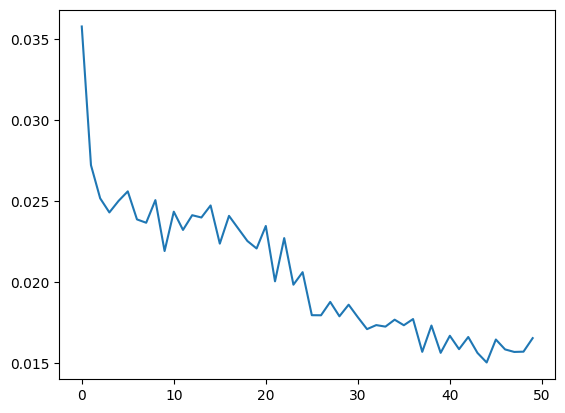

In [ ]:
loss_per_epoch = model2.history.history['loss']
plt.plot(range(len(loss_per_epoch)),loss_per_epoch)

In [ ]:
last_train_batch = scaled_train[-12:]
last_train_batch = last_train_batch.reshape((1, n_input, n_features))
print(model2.predict(last_train_batch))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step
[[0.5407343]]


In [ ]:
last_train_batch.shape

(1, 12, 1)

In [ ]:
scaled_test[0]

array([0.71707965])

In [ ]:
test_predictions = []

first_eval_batch = scaled_train[-n_input:]
current_batch = first_eval_batch.reshape((1, n_input, n_features))

for i in range(len(test)):

    # get the prediction value for the first batch
    current_pred = model2.predict(current_batch)[0]

    # append the prediction into the array
    test_predictions.append(current_pred)

    # use the prediction to update the batch and remove the first value
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━

In [ ]:
test_predictions

[array([0.5407343], dtype=float32),
 array([0.49852854], dtype=float32),
 array([0.50761616], dtype=float32),
 array([0.4321753], dtype=float32),
 array([0.34990636], dtype=float32),
 array([0.32402536], dtype=float32),
 array([0.45745945], dtype=float32),
 array([0.51440746], dtype=float32),
 array([0.49744654], dtype=float32),
 array([0.52917856], dtype=float32),
 array([0.5240138], dtype=float32),
 array([0.47877845], dtype=float32),
 array([0.48030698], dtype=float32),
 array([0.47066793], dtype=float32),
 array([0.4642732], dtype=float32),
 array([0.45394298], dtype=float32),
 array([0.41009367], dtype=float32),
 array([0.3873311], dtype=float32),
 array([0.44321215], dtype=float32),
 array([0.46559596], dtype=float32),
 array([0.46979424], dtype=float32),
 array([0.4755049], dtype=float32),
 array([0.47257507], dtype=float32),
 array([0.46343705], dtype=float32),
 array([0.4610778], dtype=float32),
 array([0.4592869], dtype=float32),
 array([0.45830545], dtype=float32),
 array([0

In [ ]:
test.head()

,Cirebon
Bulan,
2022-09-01,29929
2022-10-01,25262
2022-11-01,17969
2022-12-01,14246
2023-01-01,5816


In [ ]:
true_predictions = scaler.inverse_transform(test_predictions)
test['Predictions'] = true_predictions

<ipython-input-43-df68ac2ffec1>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


<Axes: xlabel='Bulan'>

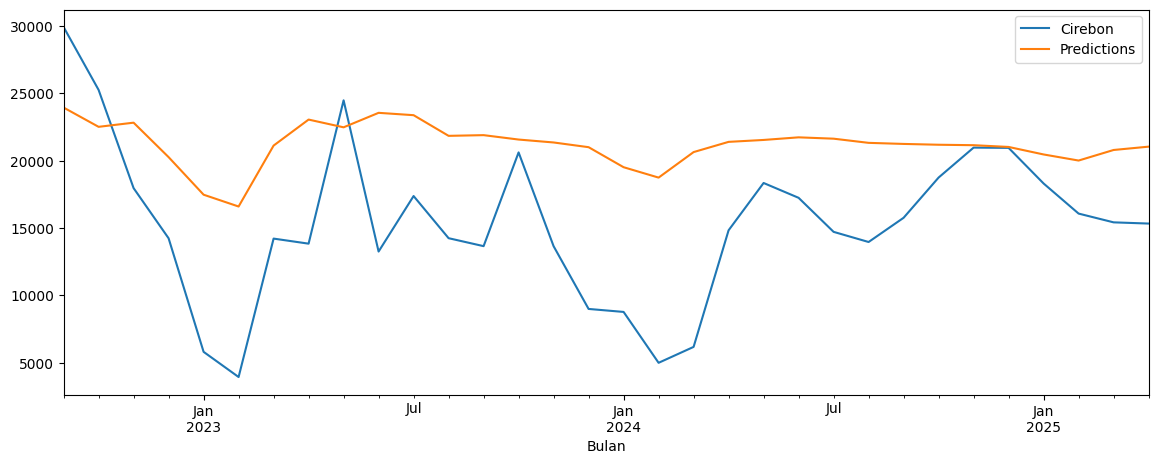

In [ ]:
test.plot(figsize=(14,5))

In [ ]:
rmse_model2=sqrt(mean_squared_error(test['Cirebon'],test['Predictions']))
print(f'Mean squared error : {rmse_model2}')

Mean squared error : 7530.676653224816


In [ ]:
test.head()

,Cirebon,Predictions
Bulan,,
2022-09-01,29929,23950.892467
2022-10-01,25262,22520.117511
2022-11-01,17969,22828.187902
2022-12-01,14246,20270.742957
2023-01-01,5816,17481.825439


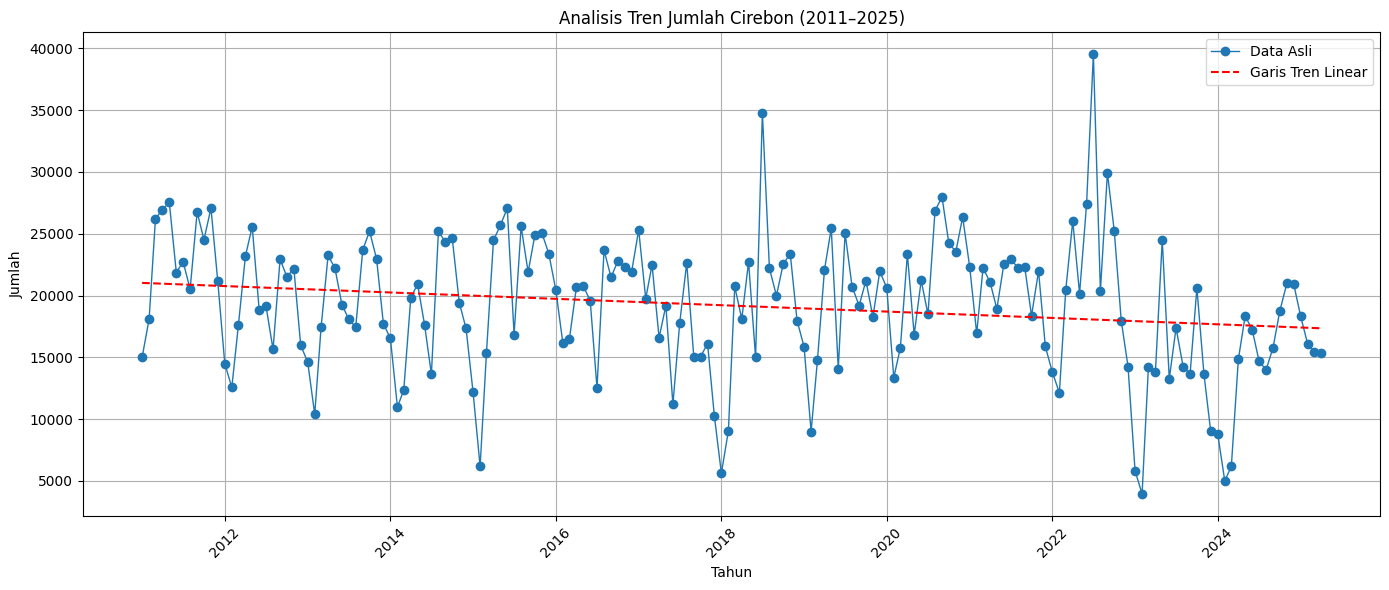

Slope tren: -21.474717173360872


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Masukkan data (pastikan tab dipakai sebagai pemisah jika dari file Excel disalin ke .txt atau CSV)
data = {
    'Bulan': pd.date_range(start='1/1/2011', periods=172, freq='MS'),  # 172 bulan dari Jan 2011
    'Cirebon': [14991,18099,26227,26939,27555,21858,22739,20520,26754,24516,27071,21156,
                14485,12567,17589,23187,25573,18805,19139,15642,22940,21524,22177,15986,
                14606,10383,17416,23242,22237,19262,18092,17449,23699,25200,22962,17723,
                16536,10978,12354,19812,20924,17611,13630,25190,24325,24643,19430,17335,
                12163,6170,15342,24457,25672,27051,16846,25588,21895,24915,25046,23400,
                20473,16189,16469,20661,20788,19579,12505,23674,21476,22797,22302,21943,
                25310,19750,22475,16581,19186,11190,17765,22642,15060,15046,16116,10244,
                5620,9065,20735,18102,22722,14992,34803,22211,19987,22558,23381,17980,
                15854,8994,14759,22067,25446,14084,25055,20715,19181,21204,18256,21961,
                20625,13364,15759,23352,16826,21218,18476,26879,27953,24233,23559,26350,
                22325,16934,22229,21082,18923,22557,22979,22253,22298,18361,21973,15877,
                13791,12128,20437,26031,20150,27407,39520,20370,29929,25262,17969,14246,
                5816,3947,14223,13847,24487,13262,17382,14253,13662,20621,13659,9001,
                8779,5002,6183,14840,18351,17250,14723,13970,15768,18754,20977,20958,
                18314,16080,15429,15339]
}

df = pd.DataFrame(data)
df['Index'] = np.arange(len(df))

# Regresi linear
model = LinearRegression()
X = df[['Index']]
y = df['Cirebon']
model.fit(X, y)
df['Trend'] = model.predict(X)

# Visualisasi tren
plt.figure(figsize=(14, 6))
plt.plot(df['Bulan'], df['Cirebon'], label='Data Asli', marker='o', linewidth=1)
plt.plot(df['Bulan'], df['Trend'], label='Garis Tren Linear', color='red', linestyle='--')
plt.title('Analisis Tren Jumlah Cirebon (2011–2025)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Tampilkan slope tren (koefisien)
print("Slope tren:", model.coef_[0])